In [2]:
from typing import List
from datetime import date
from sqlalchemy import String, Integer, ForeignKey, DECIMAL, Date
from sqlalchemy.orm import DeclarativeBase, Mapped, mapped_column, relationship
from sqlalchemy import create_engine, inspect, select
from sqlalchemy.orm import Session
from sqlalchemy import inspect
from sqlalchemy import text
import os
from pathlib import Path
import pandas as pd
from dotenv import load_dotenv
from adbc_driver_postgresql import dbapi
import pandas as pd
import os
import plotly.express as px
import plotly.io as pio
import pandas as pd

pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)
pd.options.plotting.backend = 'plotly'
pio.templates.default = 'plotly_dark+presentation'

# --- Configuration ---
BASE_DIR = Path('./')
ENV_PATH = Path().cwd().parent/"creds.env"
load_dotenv(dotenv_path=ENV_PATH)

DB_USER = os.getenv("DB_USER", "postgres")
DB_PASS = os.getenv("DB_PASS")
DB_HOST = os.getenv("DB_HOST", "localhost")
DB_NAME = os.getenv("DB_NAME", "unarxive")

CONNECTION_STRING = f"postgresql+psycopg2://{DB_USER}:{DB_PASS}@{DB_HOST}/{DB_NAME}"
engine = create_engine(CONNECTION_STRING)

In [5]:
def run_query(query: str, engine=engine) -> pd.DataFrame:
  return pd.read_sql(query, engine)

In [3]:
import pandas as pd

sql = """
    SELECT *
    FROM g_patent p
    JOIN g_attorney_disambiguated a ON p.patent_id = a.patent_id
    JOIN g_assignee_disambiguated asg ON p.patent_id = asg.patent_id
    WHERE p.patent_id = '10042595';
"""
display(pd.read_sql(text(sql), engine))

,patent_id,patent_type,patent_date,patent_title,wipo_kind,num_claims,withdrawn,filename,patent_id,attorney_sequence,...,disambig_attorney_organization,attorney_country,patent_id,assignee_sequence,assignee_id,disambig_assignee_individual_name_first,disambig_assignee_individual_name_last,disambig_assignee_organization,assignee_type,location_id
0,10042595,utility,2018-08-07,"Devices, methods, and graphical user interface...",B2,48,0,ipg180807.xml,10042595,0,...,"Morgan, Lewis & Bockius LLP",,10042595,0,3e5cae88-ed9d-4912-8c9d-de81d98a05f6,None,None,Apple Inc.,2.0,c6a61746-16c7-11ed-9b5f-1234bde3cd05


In [4]:
sql = """
    SELECT *
    FROM g_us_patent_citation
    WHERE citation_patent_id = '10042595';
"""

display(pd.read_sql(text(sql), engine))

,patent_id,citation_sequence,citation_patent_id,citation_date,record_name,wipo_kind,citation_category
0,10652385,0,10042595,2018-08-01,Behzadi,B2,cited by examiner


In [6]:
sql = """
WITH top_cited AS (
    SELECT 
        citation_patent_id,
        COUNT(DISTINCT(patent_id)) AS citation_count
    FROM g_us_patent_citation
    GROUP BY citation_patent_id
    ORDER BY citation_count DESC
    LIMIT 20
)
SELECT *
FROM top_cited t
JOIN g_patent p ON t.citation_patent_id = p.patent_id
JOIN g_attorney_disambiguated a ON t.citation_patent_id = a.patent_id
JOIN g_assignee_disambiguated asg ON t.citation_patent_id = asg.patent_id
ORDER BY t.citation_count DESC
"""

display(pd.read_sql(text(sql), engine))

,citation_patent_id,citation_count,patent_id,patent_type,patent_date,patent_title,wipo_kind,num_claims,withdrawn,filename,patent_id,attorney_sequence,attorney_id,disambig_attorney_name_first,disambig_attorney_name_last,disambig_attorney_organization,attorney_country,patent_id,assignee_sequence,assignee_id,disambig_assignee_individual_name_first,disambig_assignee_individual_name_last,disambig_assignee_organization,assignee_type,location_id
0,4683202,5784,4683202,utility,1987-07-28,Process for amplifying nucleic acid sequences,A,21,0,pftaps19870728_wk30.zip,4683202,1,574539b9c6e6fefa36bfb4a84f0588f4,Albert P.,Halluin,,,4683202,0,be1a71b8-c282-44cf-ae7b-a82d30a93619,None,None,Cetus Corporation,2.0,c7f663aa-16c7-11ed-9b5f-1234bde3cd05
1,4683202,5784,4683202,utility,1987-07-28,Process for amplifying nucleic acid sequences,A,21,0,pftaps19870728_wk30.zip,4683202,0,55f611002a893a054ebd81aafbf10072,Janet E.,Hasak,,,4683202,0,be1a71b8-c282-44cf-ae7b-a82d30a93619,None,None,Cetus Corporation,2.0,c7f663aa-16c7-11ed-9b5f-1234bde3cd05
2,4683195,5238,4683195,utility,1987-07-28,"Process for amplifying, detecting, and/or-clon...",A,26,0,pftaps19870728_wk30.zip,4683195,0,55f611002a893a054ebd81aafbf10072,Janet E.,Hasak,,,4683195,0,be1a71b8-c282-44cf-ae7b-a82d30a93619,None,None,Cetus Corporation,2.0,c7f663aa-16c7-11ed-9b5f-1234bde3cd05
3,4683195,5238,4683195,utility,1987-07-28,"Process for amplifying, detecting, and/or-clon...",A,26,0,pftaps19870728_wk30.zip,4683195,1,574539b9c6e6fefa36bfb4a84f0588f4,Albert P.,Halluin,,,4683195,0,be1a71b8-c282-44cf-ae7b-a82d30a93619,None,None,Cetus Corporation,2.0,c7f663aa-16c7-11ed-9b5f-1234bde3cd05
4,5523520,4891,5523520,utility,1996-06-04,Mutant dwarfism gene of petunia,A,20,0,pftaps19960604_wk23.zip,5523520,0,849a92c42d1623421524dbc26fc44ea0,,,"Rothwell, Figg, Ernst & Kurz",,5523520,0,3be2dc91-4af7-4603-b9c9-e36b04464e8e,None,None,"Goldsmith Seeds, Inc.",2.0,15a22f0f-16c8-11ed-9b5f-1234bde3cd05
5,7674650,4307,7674650,utility,2010-03-09,Semiconductor device and manufacturing method ...,B2,28,0,ipg100309.xml,7674650,0,d0ec2435db8a518d82eeb5cd905c6f39,,,Cook Alex Ltd.,,7674650,0,3cbd0e04-001d-46a5-986d-456478d9e140,None,None,"Semiconductor Energy Laboratory Co., Ltd.",3.0,7159b2a8-16c8-11ed-9b5f-1234bde3cd05
6,7061014,4050,7061014,utility,2006-06-13,Natural-superlattice homologous single crystal...,B2,12,0,ipg060613.xml,7061014,0,b2a3fc49e9820b0980302263ef914c24,,,"Weterman, Hattori, Daniels & Adrian, LLP.",,7061014,0,eb2ebb85-8503-414d-9730-aed37c7ab928,None,None,Japan Science and Technology Agency,3.0,a430f863-16c8-11ed-9b5f-1234bde3cd05
7,5731856,4035,5731856,utility,1998-03-24,Methods for forming liquid crystal displays in...,A,25,0,pftaps19980324_wk12.zip,5731856,0,42891b44c6faa644f70ef9c230ff1be3,,,"Myers, Bigel, Sibley & Sajovec",,5731856,0,d1d96a91-c5e6-4090-ba39-4af2494eb35c,None,None,"SAMSUNG ELECTRONICS CO., LTD.",3.0,3eea8bf8-16c8-11ed-9b5f-1234bde3cd05
8,7732819,4030,7732819,utility,2010-06-08,Semiconductor device and manufacturing method ...,B2,49,0,ipg100608.xml,7732819,0,c6bde8e25976dd208350aad111ed92e8,,,Husch Blackwell Sanders,,7732819,0,3cbd0e04-001d-46a5-986d-456478d9e140,None,None,"Semiconductor Energy Laboratory Co., Ltd.",3.0,7159b2a8-16c8-11ed-9b5f-1234bde3cd05
9,6727522,3992,6727522,utility,2004-04-27,Transistor and semiconductor device,B1,44,0,pg040427.zip,6727522,0,60001a7c83725e6a3b883b37fbc5bcb5,,,"Neifeld IP Law, P.C.",,6727522,0,7f546aca-e348-461a-8460-ca6146537efb,None,None,Japan Science and Technology,3.0,34b4468e-16c8-11ed-9b5f-1234bde3cd05


In [31]:
sql = """
WITH top_cited AS (
    SELECT 
        citation_patent_id,
        COUNT(*) AS citation_count
    FROM g_us_patent_citation
    GROUP BY citation_patent_id
    ORDER BY citation_count DESC
    LIMIT 7
)
SELECT 
    t.citation_patent_id,
    t.citation_count,
    p.patent_title,
    STRING_AGG(DISTINCT a.disambig_attorney_name_last, ', ') AS attorneys,
    STRING_AGG(DISTINCT asg.disambig_assignee_organization, ', ') AS assignees
FROM top_cited t
JOIN g_patent p ON t.citation_patent_id = p.patent_id
LEFT JOIN g_attorney_disambiguated a ON t.citation_patent_id = a.patent_id
LEFT JOIN g_assignee_disambiguated asg ON t.citation_patent_id = asg.patent_id
GROUP BY t.citation_patent_id, t.citation_count, p.patent_title
ORDER BY t.citation_count DESC
"""
display(pd.read_sql(text(sql), engine))

,citation_patent_id,citation_count,patent_title,attorneys,assignees
0,6783524,702,Robotic surgical tool with ultrasound cauteriz...,", Cassell, Esq.","INTUITIVE SURGICAL, INC."
1,5704534,686,Articulation assembly for surgical instruments,Goodwin,"Ethicon Endo-Surgery, Inc."
2,7663607,680,Multipoint touchscreen,,Apple Inc.
3,7404508,666,Surgical stapling and cutting device,", Mayback, Smiley","Ethicon Endo-Surgery, Inc."
4,5632432,663,Surgical instrument,Coletti,"Ethicon Endo-Surgery, Inc."
5,5312023,662,Self contained gas powered surgical apparatus,None,United States Surgical Corporation
6,7674650,659,Semiconductor device and manufacturing method ...,,"Semiconductor Energy Laboratory Co., Ltd."


In [10]:
sql = """
    SELECT 
        EXTRACT(YEAR FROM patent_date) AS year,
        COUNT(*) AS patent_count
    FROM g_patent
    GROUP BY EXTRACT(YEAR FROM patent_date)
    ORDER BY year ASC
"""
patent_year_df = pd.read_sql(text(sql), engine)
display(patent_year_df)

,year,patent_count
0,1976.0,70941
1,1977.0,69820
2,1978.0,70586
3,1979.0,52484
4,1980.0,66212
5,1981.0,71112
6,1982.0,63292
7,1983.0,62019
8,1984.0,72689
9,1985.0,77276


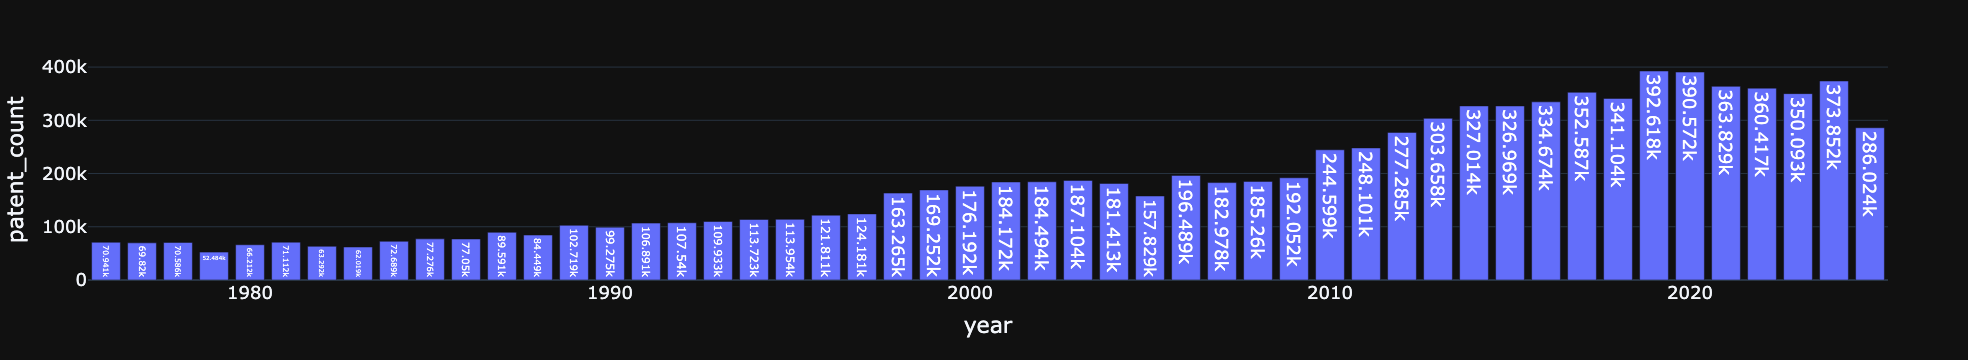

In [11]:
patent_year_df.sort_values(by="year").plot.bar(x="year", y="patent_count", text_auto=True)

In [12]:
sql = """
    SELECT 
        citation_patent_id,
        citation_category,
        COUNT(*) AS citation_count
        FROM g_us_patent_citation
        WHERE citation_patent_id IN ('6783524', '6323846', '7663607')
        GROUP BY citation_patent_id, citation_category
"""
df = pd.read_sql(text(sql), engine)
display(df)


,citation_patent_id,citation_category,citation_count
0,6323846,cited by applicant,618
1,6323846,cited by examiner,26
2,6783524,cited by applicant,696
3,6783524,cited by examiner,6
4,7663607,cited by applicant,672
5,7663607,cited by examiner,8


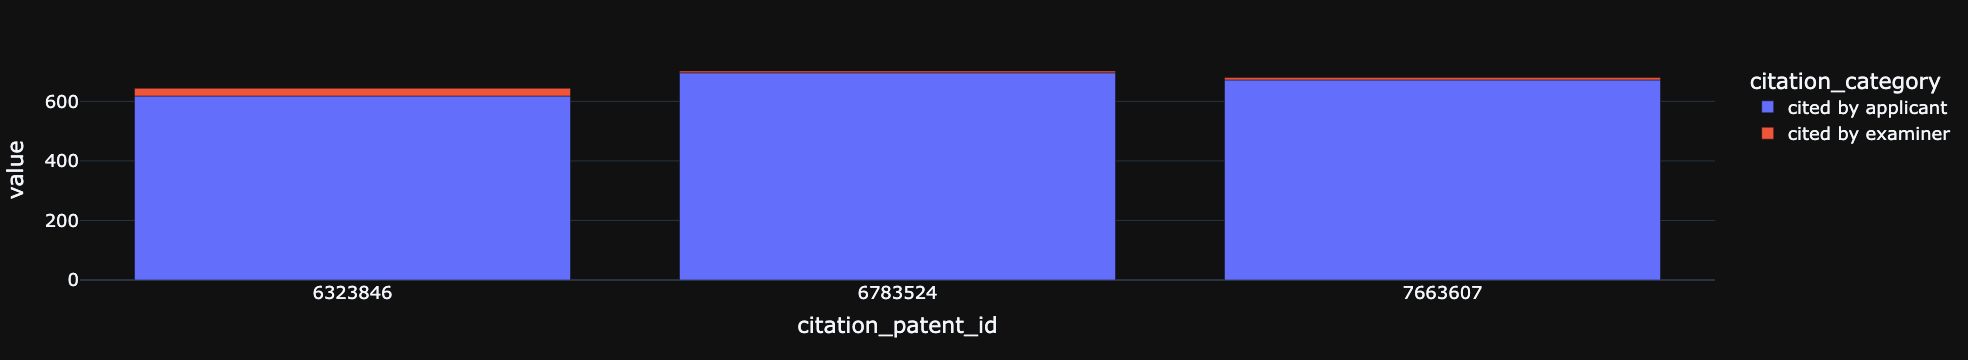

In [10]:
df.pivot(index="citation_patent_id", columns="citation_category", values="citation_count").plot.bar()

In [5]:
sql = """
    SELECT location_id, disambig_state
    FROM g_location_disambiguated
    WHERE disambig_city = 'Chicago'
    """
display(pd.read_sql(text(sql), engine))

,location_id,disambig_state
0,e1c05366-16c7-11ed-9b5f-1234bde3cd05,IL


In [6]:
sql = """
    SELECT COUNT(DISTINCT i.patent_id) as patent_count
    FROM g_inventor_disambiguated i
    JOIN g_location_disambiguated l ON i.location_id = l.location_id
    WHERE l.disambig_city = 'Chicago'
    """
display(pd.read_sql(text(sql), engine))

,patent_count
0,47516


In [12]:
sql = """
SELECT 
    asg.disambig_assignee_organization,
    COUNT(DISTINCT asg.patent_id) AS patent_count
FROM g_assignee_disambiguated asg
JOIN g_location_disambiguated l ON asg.location_id = l.location_id
WHERE l.disambig_state = 'NJ'
GROUP BY asg.disambig_assignee_organization
ORDER BY patent_count DESC
LIMIT 5
"""
display(pd.read_sql(text(sql), engine))

,disambig_assignee_organization,patent_count
0,HONEYWELL INTERNATIONAL INC.,12929
1,LUCENT TECHNOLOGIES INC.,9353
2,Verizon Patent and Licensing Inc.,6482
3,"Becton, Dickinson and Company",5007
4,Hoffmann-La Roche Inc.,4922


In [23]:
sql = """
SELECT 
    asg.disambig_assignee_organization,
    COUNT(DISTINCT asg.patent_id) AS patent_count
FROM g_assignee_disambiguated asg
JOIN g_location_disambiguated l ON asg.location_id = l.location_id
WHERE l.disambig_city = 'Chicago'
GROUP BY asg.disambig_assignee_organization
ORDER BY patent_count DESC
LIMIT 5
"""
display(pd.read_sql(text(sql), engine))

,disambig_assignee_organization,patent_count
0,The Boeing Company,16966
1,Motorola Mobility LLC,1547
2,Amoco Corporation,1508
3,"MOTOROLA SOLUTIONS, INC.",1269
4,Standard Oil Company (Indiana),1038


In [24]:
sql = """
SELECT 
    asg.disambig_assignee_organization,
    COUNT(DISTINCT asg.patent_id) AS patent_count
FROM g_assignee_disambiguated asg
JOIN g_location_disambiguated l ON asg.location_id = l.location_id
WHERE l.disambig_country = 'US'
GROUP BY asg.disambig_assignee_organization
ORDER BY patent_count DESC
LIMIT 5
"""
display(pd.read_sql(text(sql), engine))

,disambig_assignee_organization,patent_count
0,International Business Machines Corporation,163481
1,Intel Corporation,52632
2,General Electric Company,51761
3,None,42026
4,QUALCOMM Incorporated,40718
